# Benchmarks Comparados — Suite Actual vs. Suite Propuesta

**Hackathon AI Telecom Challenge 2026 — Desafio 02**

## Objetivo

Tomar **el mismo modelo** — la logistica corregida de `EDA_logistica_corregida.ipynb`, en sus tres variantes de escalado — y medirlo bajo **dos suites de metricas distintas**, para mostrar cuanto de lo que hoy se reporta es informacion real y cuanto es artefacto del diseno de la evaluacion.

| | Suite A (actual) | Suite B (propuesta) |
|---|---|---|
| Unidad | fila `(cliente, oferta, canal)` | **cliente** |
| Agrupacion | pooled entre clientes | dentro del cliente |
| Metricas | ROC-AUC, PR-AUC, Brier, log-loss, P/R/F1 @0.5 | piso trivial, AUC estratificada, AUC de offset, Recall@k, escalera de baselines, valor @ presupuesto, ECE por segmento, cobertura de catalogo |

## La hipotesis a falsear

El ROC-AUC global reportado (~0.590) se sostiene casi entero sobre `oferta_es_mt`, un booleano deterministico conocido **antes** de scorear. En `metricas_segmentos.csv` la AUC dentro del segmento no-MT — 89% de las filas — cae a 0.531.

Si eso es cierto:

1. Un predictor de **un solo bit** deberia acercarse mucho al ROC-AUC del modelo de 31 features.
2. Las tres variantes de escalado, indistinguibles bajo la Suite A, deberian seguir siendo indistinguibles bajo la Suite B — porque el problema no es el escalado.
3. Una tabla de popularidad por segmento, sin ML, deberia empatar al modelo en ranking.

Este notebook produce los numeros para confirmar o descartar cada punto.

## Alcance

No modifica el motor ni reentrena el artefacto en produccion. Escribe resultados en `data/processed/benchmarks_comparados/`.

In [1]:
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score,
)
from sklearn.base import clone

import lightgbm as lgb

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 1000)

RANDOM_STATE = 42
DIR_SALIDA = Path("../data/processed/benchmarks_comparados")
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

def logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))

def clave(df, cols):
    """Clave string estable para joins de tablas de frecuencia."""
    return df[cols].astype(str).agg("|".join, axis=1)

## 1. Reconstruccion exacta del modelado de `EDA_logistica_corregida.ipynb`

Misma limpieza, mismo target, mismas features, mismo split y mismos folds. Cualquier diferencia en los numeros vendria de la metrica, no de los datos.

In [2]:
clientes = pd.read_csv("../data/raw/dataset_clientes.csv")
catalogo = pd.read_csv("../data/raw/catalogo_ofertas_entrega.csv")
campanias = pd.read_csv("../data/raw/historial_campanias.csv", parse_dates=["fecha"])

ids = ["cliente_id", "oferta_id", "ofrecimiento_id", "oferta_hogar_id", "plan_actual_id"]
for df in (clientes, catalogo, campanias):
    for col in df.select_dtypes(include=["object", "str"]).columns:
        if col not in ids:
            df[col] = df[col].astype(str).str.strip().str.lower()

# pandas 3 rechaza escribir texto en columnas float64 (p.ej. una columna 100% nula).
# El notebook original asume dtype object; se fuerza antes de recodificar.
for _df, _cols in ((clientes, ["oferta_hogar_id", "tipo_cliente", "canal_mas_usado"]),
                   (catalogo, ["cluster_hogar", "descripcion_bundle"])):
    for _c in _cols:
        _df[_c] = _df[_c].astype(object)

clientes.loc[clientes["oferta_hogar_id"].isna() & (clientes["tiene_hogar"] == False), "oferta_hogar_id"] = "sin_servicio_hogar"
clientes.loc[clientes["tipo_cliente"].isna() & (clientes["tiene_movil"] == False), "tipo_cliente"] = "sin_movil"
clientes.loc[clientes["canal_mas_usado"].isna() & (clientes["n_actividad_canal"] == 0), "canal_mas_usado"] = "sin_actividad"
catalogo.loc[catalogo["cluster_hogar"].isna() & (catalogo["tipo_oferta"] != "plan_hogar"), "cluster_hogar"] = "no_aplica"
catalogo.loc[catalogo["descripcion_bundle"].isna() & (catalogo["tipo_oferta"] != "plan_hogar"), "descripcion_bundle"] = "no_aplica"

analitica = campanias.merge(clientes, on="cliente_id", how="left", suffixes=("_camp", "_cli"))
for col in ["tipo_cliente", "antiguedad_meses", "elegible_mt", "es_movistar_total"]:
    analitica[col] = analitica[f"{col}_cli"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cli"])

catalogo_join = catalogo.rename(columns={"es_movistar_total": "oferta_catalogo_es_mt"})
analitica = analitica.merge(catalogo_join, on="oferta_id", how="left", suffixes=("_camp", "_cat"))
for col in ["nombre_oferta", "tipo_oferta"]:
    analitica[col] = analitica[f"{col}_cat"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cat"])

analitica["target_aceptacion"] = np.nan
analitica.loc[analitica["resultado"] == "aceptada", "target_aceptacion"] = 1
analitica.loc[analitica["resultado"] == "rechazada", "target_aceptacion"] = 0
mask_rebate = analitica["es_rebate"].astype(str).str.lower().isin(["true", "1"])
filas_resultado_observado = int(analitica["target_aceptacion"].notna().sum())
rebates_excluidos = int((analitica["target_aceptacion"].notna() & mask_rebate).sum())
base_target = analitica[analitica["target_aceptacion"].notna() & ~mask_rebate].copy()
base_target["target_aceptacion"] = base_target["target_aceptacion"].astype(int)

assert not base_target["es_rebate"].astype(str).str.lower().isin(["true", "1"]).any()
print(f"Resultados aceptada/rechazada antes del filtro: {filas_resultado_observado:,}")
print(f"Rebates estructuralmente rechazados excluidos: {rebates_excluidos:,}")
print(f"Filas de modelado: {len(base_target):,}")
print(f"Tasa de aceptacion global (politica historica): {base_target['target_aceptacion'].mean():.4f}")

Resultados aceptada/rechazada antes del filtro: 254,618
Rebates estructuralmente rechazados excluidos: 47,572
Filas de modelado: 207,046
Tasa de aceptacion global (politica historica): 0.4608


In [3]:
modelado = base_target.copy()
modelado["oferta_ilimitada"] = modelado["gb_incluidos"] == 9999
modelado["gb_incluidos_modelo"] = modelado["gb_incluidos"].replace(9999, np.nan)

NUMERICAS = [
    "antiguedad_meses", "monto_facturado_prom", "consumo_datos_gb_prom",
    "consumo_voz_min_prom", "consumo_sms_prom", "uso_app_movistar_prom",
    "dias_mora_prom", "precio_mensual", "ahorro_pct", "gb_incluidos_modelo",
]
CATEGORICAS = [
    "tipo_cliente", "tiene_movil", "tiene_hogar", "oferta_hogar_id",
    "tiene_internet_hogar", "es_movistar_total", "elegible_mt",
    "plan_actual_id", "edad_rango", "ubicacion_departamento",
    "es_usuario_app", "meses_moroso", "n_reclamos", "n_actividad_canal",
    "canal_mas_usado", "oferta_id", "canal", "tipo_oferta",
    "oferta_es_mt", "segmento_objetivo", "cluster_hogar", "oferta_ilimitada",
]

X = modelado[NUMERICAS + CATEGORICAS].copy()
for c in CATEGORICAS:
    X[c] = X[c].astype(str)
y = modelado["target_aceptacion"].astype(int)
grupos = modelado["cliente_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_test = next(splitter.split(X, y, groups=grupos))

X_train = X.iloc[idx_train].reset_index(drop=True)
y_train = y.iloc[idx_train].reset_index(drop=True)
g_train = grupos.iloc[idx_train].reset_index(drop=True)
meta = modelado.iloc[idx_train].reset_index(drop=True)   # columnas de negocio para la Suite B

gkf = GroupKFold(n_splits=5)
FOLDS = list(gkf.split(X_train, y_train, groups=g_train))

print(f"Train: {len(X_train):,} filas / {g_train.nunique():,} clientes")
print(f"Test reservado (NO se abre): {len(idx_test):,} filas")

Train: 165,740 filas / 69,921 clientes
Test reservado (NO se abre): 41,306 filas


## 2. Las tres variantes de la logistica corregida

`StandardScaler` (original), `RobustScaler` y `QuantileTransformer`. El notebook de origen concluyo que las metricas discriminativas quedaban "practicamente invariantes" entre las tres. La Suite B tiene que reproducir esa conclusion — si no lo hace, es la Suite B la que esta mal.

In [4]:
pipe_cat = Pipeline([
    ("imp", SimpleImputer(strategy="constant", fill_value="faltante")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

ESCALADORES = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "quantile": QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE),
}

def construir(escalador):
    preproc = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", escalador)]), NUMERICAS),
        ("cat", pipe_cat, CATEGORICAS),
    ])
    return Pipeline([
        ("preproc", preproc),
        ("clf", LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)),
    ])

def oof_proba(pipeline):
    p = np.zeros(len(X_train))
    for idx_fit, idx_val in FOLDS:
        cand = clone(pipeline)
        cand.fit(X_train.iloc[idx_fit], y_train.iloc[idx_fit])
        p[idx_val] = cand.predict_proba(X_train.iloc[idx_val])[:, 1]
    return p

SCORES = {}
for nombre, esc in ESCALADORES.items():
    print(f"OOF logistica_{nombre} ...")
    SCORES[f"logistica_{nombre}"] = oof_proba(construir(clone(esc)))

# Reconstruccion OOF del candidato vigente: 31 variables, sin identidad oferta_id.
CATEGORICAS_GENERALIZABLE = [c for c in CATEGORICAS if c != "oferta_id"]
COLUMNAS_GENERALIZABLE = NUMERICAS + CATEGORICAS_GENERALIZABLE

def construir_generalizable():
    preproc = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), NUMERICAS),
        ("cat", pipe_cat, CATEGORICAS_GENERALIZABLE),
    ])
    return Pipeline([
        ("preproc", preproc),
        ("clf", LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)),
    ])

def oof_generalizable():
    p = np.zeros(len(X_train))
    for idx_fit, idx_val in FOLDS:
        cand = construir_generalizable()
        cand.fit(X_train.iloc[idx_fit][COLUMNAS_GENERALIZABLE], y_train.iloc[idx_fit])
        p[idx_val] = cand.predict_proba(X_train.iloc[idx_val][COLUMNAS_GENERALIZABLE])[:, 1]
    return p

print("OOF modelo_motor_generalizable_31 ...")
SCORES["modelo_motor_generalizable_31"] = oof_generalizable()
print("Listo:", list(SCORES))

OOF logistica_standard ...


OOF logistica_robust ...


OOF logistica_quantile ...


OOF modelo_motor_generalizable_31 ...


Listo: ['logistica_standard', 'logistica_robust', 'logistica_quantile', 'modelo_motor_generalizable_31']


## 3. SUITE A — las metricas que se reportan hoy

Fila a fila, agrupando todos los clientes en un solo pool. Es exactamente lo que calcula `evaluar_esquema()` en el notebook original y lo que hay en `comparacion_candidatos.csv`.

In [5]:
def suite_a(y_true, p):
    pred = (p >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, p),
        "pr_auc": average_precision_score(y_true, p),
        "brier": brier_score_loss(y_true, p),
        "log_loss": log_loss(y_true, p),
        "precision_05": precision_score(y_true, pred, zero_division=0),
        "recall_05": recall_score(y_true, pred, zero_division=0),
        "f1_05": f1_score(y_true, pred, zero_division=0),
    }

tabla_a = pd.DataFrame({n: suite_a(y_train, p) for n, p in SCORES.items()}).T
print("SUITE A — metricas actuales")
print(tabla_a.round(4).to_string())
print()
rango = (tabla_a.max() - tabla_a.min()).round(5)
print("Rango (max - min) entre las tres variantes:")
print(rango.to_string())
print()
print("Punto 2 de la hipotesis: si estos rangos son ~0, la Suite A no distingue las variantes.")

SUITE A — metricas actuales
                               roc_auc  pr_auc   brier  log_loss  precision_05  recall_05   f1_05
logistica_standard              0.5909  0.5793  0.2365    0.6651        0.7569     0.1788  0.2893
logistica_robust                0.5909  0.5794  0.2365    0.6651        0.7570     0.1787  0.2892
logistica_quantile              0.5895  0.5785  0.2366    0.6653        0.7513     0.1812  0.2920
modelo_motor_generalizable_31   0.5913  0.5797  0.2365    0.6650        0.7585     0.1785  0.2890

Rango (max - min) entre las tres variantes:
roc_auc         0.00172
pr_auc          0.00117
brier           0.00013
log_loss        0.00029
precision_05    0.00726
recall_05       0.00272
f1_05           0.00301

Punto 2 de la hipotesis: si estos rangos son ~0, la Suite A no distingue las variantes.


## 4. SUITE B

### 4.1 Piso de trivialidad — cuanta AUC compra un solo bit

Predictor: `oferta_es_mt`, un booleano del catalogo, sin entrenamiento, sin cliente, sin canal. Se compara contra el modelo completo. La diferencia es todo lo que las 31 features aportan sobre saber el tipo de producto.

Ademas se calcula la **AUC estratificada**: se computa dentro de cada segmento y se pondera por la varianza binomial del segmento. Esa version no puede cobrar credito por separar poblaciones que ya venian separadas.

In [6]:
bit_mt = meta["oferta_es_mt"].astype(str).str.lower().isin(["true", "1"]).astype(float).to_numpy()
auc_trivial = roc_auc_score(y_train, bit_mt)
print(f"ROC-AUC del predictor de 1 bit (oferta_es_mt): {auc_trivial:.4f}")
print()

def auc_estratificada(y_true, p, segmento):
    filas, pesos = [], []
    for val, idx in pd.Series(segmento).groupby(pd.Series(segmento)).groups.items():
        idx = np.asarray(idx)
        yy = np.asarray(y_true)[idx]
        if len(np.unique(yy)) < 2:
            continue
        tasa = yy.mean()
        filas.append(roc_auc_score(yy, np.asarray(p)[idx]))
        pesos.append(len(idx) * tasa * (1 - tasa))
    return float(np.average(filas, weights=pesos))

filas_b1 = []
for nombre, p in SCORES.items():
    filas_b1.append({
        "modelo": nombre,
        "auc_global": roc_auc_score(y_train, p),
        "auc_trivial_1bit": auc_trivial,
        "ganancia_sobre_1bit": roc_auc_score(y_train, p) - auc_trivial,
        "auc_estratif_por_mt": auc_estratificada(y_train, p, meta["oferta_es_mt"].astype(str)),
        "auc_estratif_por_tipo_oferta": auc_estratificada(y_train, p, meta["tipo_oferta"].astype(str)),
        "auc_estratif_por_tipo_x_canal": auc_estratificada(
            y_train, p, clave(meta, ["tipo_oferta", "canal"])),
    })

tabla_b1 = pd.DataFrame(filas_b1).set_index("modelo")
print("SUITE B.1 — piso de trivialidad y AUC estratificada")
print(tabla_b1.round(4).to_string())

ROC-AUC del predictor de 1 bit (oferta_es_mt): 0.5650



SUITE B.1 — piso de trivialidad y AUC estratificada
                               auc_global  auc_trivial_1bit  ganancia_sobre_1bit  auc_estratif_por_mt  auc_estratif_por_tipo_oferta  auc_estratif_por_tipo_x_canal
modelo                                                                                                                                                            
logistica_standard                 0.5909             0.565               0.0259               0.5350                        0.5349                         0.5349
logistica_robust                   0.5909             0.565               0.0259               0.5350                        0.5349                         0.5349
logistica_quantile                 0.5895             0.565               0.0245               0.5333                        0.5333                         0.5333
modelo_motor_generalizable_31      0.5913             0.565               0.0263               0.5355                        0.5354  

### 4.2 Modelo con offset — discriminacion de personalizacion pura

Se fija `logit(P(acepta | oferta_id, canal))` como **offset** (`init_score` en LightGBM), estimado solo en los folds de ajuste. El modelo queda obligado a ganar AUC unicamente con variables de cliente: no puede volver a derivar la tabla de popularidad, ya se la dieron.

La `auc_offset_solo` es lo que sabe la tabla de popularidad. La `auc_con_cliente` es lo que sabe la tabla mas el cliente. **La diferencia es la personalizacion**, y es el numero honesto que hoy no se reporta.

In [7]:
CLIENTE_NUM = ["antiguedad_meses", "monto_facturado_prom", "consumo_datos_gb_prom",
               "consumo_voz_min_prom", "consumo_sms_prom", "uso_app_movistar_prom",
               "dias_mora_prom"]
CLIENTE_CAT = ["tipo_cliente", "tiene_movil", "tiene_hogar", "tiene_internet_hogar",
               "es_movistar_total", "elegible_mt", "plan_actual_id", "edad_rango",
               "ubicacion_departamento", "es_usuario_app", "meses_moroso",
               "n_reclamos", "canal_mas_usado"]

X_cli = X_train[CLIENTE_NUM + CLIENTE_CAT].copy()
for c in CLIENTE_CAT:
    X_cli[c] = X_cli[c].astype("category")   # categorias globales -> consistentes entre folds

k_off = clave(meta, ["oferta_id", "canal"])
oof_offset_solo = np.zeros(len(X_train))
oof_con_cliente = np.zeros(len(X_train))

params = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              min_data_in_leaf=100, feature_fraction=0.8, bagging_fraction=0.8,
              bagging_freq=1, lambda_l2=1.0, verbose=-1, seed=RANDOM_STATE)

for idx_fit, idx_val in FOLDS:
    tasa = y_train.iloc[idx_fit].groupby(k_off.iloc[idx_fit]).mean()
    glob = y_train.iloc[idx_fit].mean()
    off_fit = logit(k_off.iloc[idx_fit].map(tasa).fillna(glob).to_numpy())
    off_val = logit(k_off.iloc[idx_val].map(tasa).fillna(glob).to_numpy())

    ds = lgb.Dataset(X_cli.iloc[idx_fit], label=y_train.iloc[idx_fit], init_score=off_fit)
    booster = lgb.train(params, ds, num_boost_round=300)
    raw = booster.predict(X_cli.iloc[idx_val], raw_score=True)

    oof_offset_solo[idx_val] = 1 / (1 + np.exp(-off_val))
    oof_con_cliente[idx_val] = 1 / (1 + np.exp(-(off_val + raw)))

auc_off = roc_auc_score(y_train, oof_offset_solo)
auc_cli = roc_auc_score(y_train, oof_con_cliente)
SCORES["offset_mas_cliente"] = oof_con_cliente

print(f"AUC solo con la tabla de popularidad (oferta x canal): {auc_off:.4f}")
print(f"AUC de la tabla + informacion de cliente:              {auc_cli:.4f}")
print(f"APORTE REAL DE LA PERSONALIZACION:                     {auc_cli - auc_off:+.4f}")

AUC solo con la tabla de popularidad (oferta x canal): 0.5650
AUC de la tabla + informacion de cliente:              0.5834
APORTE REAL DE LA PERSONALIZACION:                     +0.0185


### 4.3 Ranking dentro del cliente — Recall@k, MRR, NDCG@3

La unidad de evaluacion pasa a ser el **cliente**, que es la unidad de decision del producto: el motor entrega un Top-3 por cliente, no una clasificacion de filas.

Universo: clientes con al menos 2 ofertas distintas registradas y al menos una aceptacion. Se ordenan sus ofrecimientos por score y se pregunta si una aceptada cae en el Top-k.

**Limitacion, explicita.** El conjunto candidato es el de ofertas **efectivamente registradas** para ese cliente, no las 22 del catalogo, porque solo ahi hay ground truth. Es un estimador de tipo *replay*: mide orden dentro de lo observado. Rankear el catalogo completo requiere evaluacion off-policy (seccion 6).

In [8]:
eval_df = pd.DataFrame({
    "cliente_id": g_train.to_numpy(),
    "oferta_id": meta["oferta_id"].to_numpy(),
    "y": y_train.to_numpy(),
    "precio": meta["precio_mensual"].to_numpy(),
})

n_ofertas = eval_df.groupby("cliente_id")["oferta_id"].transform("nunique")
n_acepta = eval_df.groupby("cliente_id")["y"].transform("sum")
mask_rank = (n_ofertas >= 2) & (n_acepta >= 1)
idx_rank = np.where(mask_rank.to_numpy())[0]

print(f"Clientes evaluables para ranking: {eval_df.loc[idx_rank, 'cliente_id'].nunique():,}")
print(f"Filas involucradas: {len(idx_rank):,}")

def metricas_ranking(score, df_base=None, ks=(1, 2, 3)):
    """Recall@k, MRR y NDCG@3 dentro del cliente.

    df_base=None usa el universo completo (eval_df). Se puede pasar un
    subconjunto -- p.ej. solo el periodo de evaluacion temporal -- y el
    filtro de elegibilidad (>=2 ofertas, >=1 aceptacion) se recalcula
    dentro de ese subconjunto en vez de sobre todo el train.
    """
    base = eval_df if df_base is None else df_base
    d = base.copy()
    d["s"] = np.asarray(score)
    elegible = (
        (d.groupby("cliente_id")["oferta_id"].transform("nunique") >= 2)
        & (d.groupby("cliente_id")["y"].transform("sum") >= 1)
    )
    d = d[elegible]
    # Desempate reproducible para no premiar el orden original del log
    d["tie"] = np.random.default_rng(RANDOM_STATE).random(len(d))
    d = d.sort_values(["cliente_id", "s", "tie"], ascending=[True, False, True])
    d["rank"] = d.groupby("cliente_id").cumcount() + 1

    aceptadas = d[d["y"] == 1]
    mejor_rank = aceptadas.groupby("cliente_id")["rank"].min()

    out = {f"recall@{k}": float((mejor_rank <= k).mean()) for k in ks}
    out["mrr"] = float((1.0 / mejor_rank).mean())

    # NDCG@3 con relevancia binaria
    def ndcg3(gr):
        rel = gr.sort_values(["s", "tie"], ascending=[False, True])["y"].to_numpy()[:3]
        dcg = np.sum(rel / np.log2(np.arange(2, len(rel) + 2)))
        ideal = np.sort(gr["y"].to_numpy())[::-1][:3]
        idcg = np.sum(ideal / np.log2(np.arange(2, len(ideal) + 2)))
        return dcg / idcg if idcg > 0 else 0.0

    out["ndcg@3"] = float(d.groupby("cliente_id")[["s", "tie", "y"]].apply(ndcg3).mean())
    out["n_clientes_evaluables"] = int(d["cliente_id"].nunique())
    return out

tabla_b3 = pd.DataFrame({n: metricas_ranking(p) for n, p in SCORES.items()}).T
print()
print("SUITE B.3 — ranking dentro del cliente")
print(tabla_b3.round(4).to_string())

Clientes evaluables para ranking: 37,715
Filas involucradas: 117,179



SUITE B.3 — ranking dentro del cliente
                               recall@1  recall@2  recall@3     mrr  ndcg@3  n_clientes_evaluables
logistica_standard               0.5846    0.8808    0.9709  0.7697  0.7829                37715.0
logistica_robust                 0.5843    0.8806    0.9710  0.7695  0.7827                37715.0
logistica_quantile               0.5841    0.8801    0.9709  0.7693  0.7828                37715.0
modelo_motor_generalizable_31    0.5881    0.8787    0.9703  0.7711  0.7837                37715.0
offset_mas_cliente               0.5896    0.8805    0.9715  0.7722  0.7846                37715.0


### 4.4 Escalera de baselines — la comparacion que decide

Sin esta escalera ninguna metrica significa nada: un Recall@3 de 0.75 puede ser excelente o puede ser lo que da elegir al azar entre 4 ofertas.

| | Politica |
|---|---|
| B0 | Aleatorio dentro del conjunto candidato |
| B1 | Popularidad global `P(acepta \| oferta)` — sin personalizar |
| B2 | Proxy de la regla de negocio: MT primero, luego mayor `ahorro_pct` |
| B3 | Popularidad por segmento `P(acepta \| oferta, elegible_mt, canal)` — una tabla, cero ML |
| B4+ | Los modelos |

Todas las tablas de frecuencia se estiman **solo en los folds de ajuste**, con el mismo `FOLDS`, para que la comparacion sea limpia.

In [9]:
def oof_tabla_frecuencia(cols):
    """Score OOF = P(acepta | cols), estimado unicamente en folds de ajuste."""
    k = clave(meta, cols)
    s = np.zeros(len(X_train))
    for idx_fit, idx_val in FOLDS:
        tasa = y_train.iloc[idx_fit].groupby(k.iloc[idx_fit]).mean()
        glob = y_train.iloc[idx_fit].mean()
        s[idx_val] = k.iloc[idx_val].map(tasa).fillna(glob).to_numpy()
    return s

rng = np.random.default_rng(RANDOM_STATE)
POLITICAS = {
    "B0_aleatorio": rng.random(len(X_train)),
    "B1_popularidad_oferta": oof_tabla_frecuencia(["oferta_id"]),
    "B2_regla_mt_primero": (
        meta["oferta_es_mt"].astype(str).str.lower().isin(["true", "1"]).astype(float) * 100
        + meta["ahorro_pct"].fillna(0).astype(float)
    ).to_numpy(),
    "B3_popularidad_segmento": oof_tabla_frecuencia(["oferta_id", "elegible_mt", "canal"]),
}
POLITICAS.update(SCORES)

tabla_b4 = pd.DataFrame({n: metricas_ranking(p) for n, p in POLITICAS.items()}).T
tabla_b4 = tabla_b4.sort_values("recall@3", ascending=False)
print("SUITE B.4 — escalera de baselines (ordenada por recall@3)")
print(tabla_b4.round(4).to_string())
print()
ref = tabla_b4.loc["B3_popularidad_segmento", "recall@3"]
print("Delta de recall@3 contra B3 (tabla de popularidad, sin ML):")
print((tabla_b4["recall@3"] - ref).round(4).to_string())
print()
print("Punto 3 de la hipotesis: si los modelos no superan a B3, el ML no esta")
print("aportando personalizacion sobre una tabla de frecuencias.")

SUITE B.4 — escalera de baselines (ordenada por recall@3)
                               recall@1  recall@2  recall@3     mrr  ndcg@3  n_clientes_evaluables
B2_regla_mt_primero              0.5888    0.8839    0.9735  0.7726  0.7858                37715.0
offset_mas_cliente               0.5896    0.8805    0.9715  0.7722  0.7846                37715.0
B0_aleatorio                     0.5725    0.8756    0.9715  0.7628  0.7760                37715.0
B1_popularidad_oferta            0.5866    0.8806    0.9712  0.7707  0.7831                37715.0
logistica_robust                 0.5843    0.8806    0.9710  0.7695  0.7827                37715.0
logistica_quantile               0.5841    0.8801    0.9709  0.7693  0.7828                37715.0
logistica_standard               0.5846    0.8808    0.9709  0.7697  0.7829                37715.0
B3_popularidad_segmento          0.5893    0.8808    0.9708  0.7720  0.7845                37715.0
modelo_motor_generalizable_31    0.5881    0.8787  

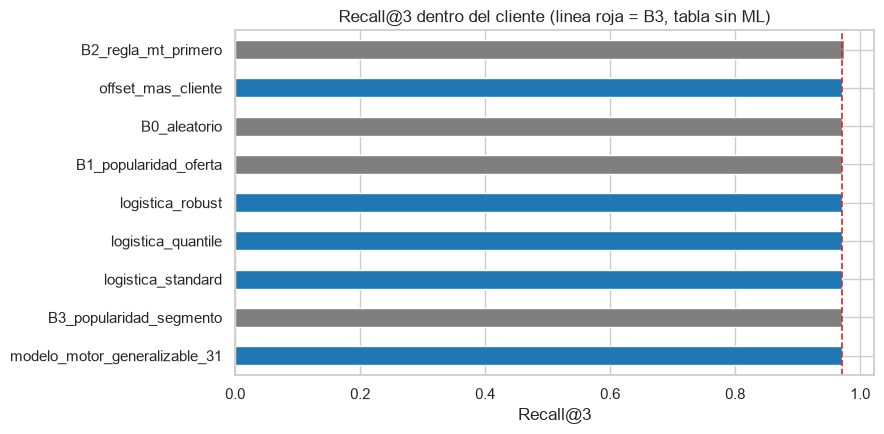

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden = tabla_b4["recall@3"].sort_values()
colores = ["#7f7f7f" if i.startswith("B") else "#1f77b4" for i in orden.index]
orden.plot(kind="barh", ax=ax, color=colores)
ax.axvline(ref, ls="--", c="#d62728", lw=1.2)
ax.set_title("Recall@3 dentro del cliente (linea roja = B3, tabla sin ML)")
ax.set_xlabel("Recall@3")
plt.tight_layout()
plt.show()

### 4.5 Valor esperado a presupuesto de contactos

Nadie contacta a 100,000 clientes. La pregunta operativa es: **con presupuesto para N contactos, cuanto valor captura cada politica.**

Procedimiento: cada politica elige su Top-1 por cliente, los clientes se ordenan por ese score, se toman los N primeros y se suma el resultado real de ese ofrecimiento. Es el mismo estimador de *replay* de la seccion anterior, ahora en unidades de negocio: aceptaciones y PEN/mes.

`lift_top10 = 1.68` del reporte actual es un caso particular de esta curva; la curva completa tiene resolucion donde el escalar no la tiene.

SUITE B.5 — valor capturado por presupuesto (PEN/mes)
                               pen_mes@1000  pen_mes@5000  pen_mes@10000  pen_mes@20000  pen_mes@50000
B0_aleatorio                        36920.0      200508.0       403785.0       811173.0      2006522.0
B1_popularidad_oferta              142284.0      663898.0      1300443.0      1650738.0      2589224.0
B2_regla_mt_primero                175184.0      851223.0      1380202.0      1667166.0      2519068.0
B3_popularidad_segmento            114374.0      703039.0      1283163.0      1659944.0      2426745.0
logistica_standard                 139740.0      708036.0      1248883.0      1579065.0      2502389.0
logistica_robust                   142300.0      714377.0      1256848.0      1587177.0      2510418.0
logistica_quantile                 144070.0      715525.0      1255090.0      1588195.0      2500682.0
modelo_motor_generalizable_31      142880.0      720306.0      1266232.0      1599472.0      2525202.0
offset_mas_cliente 

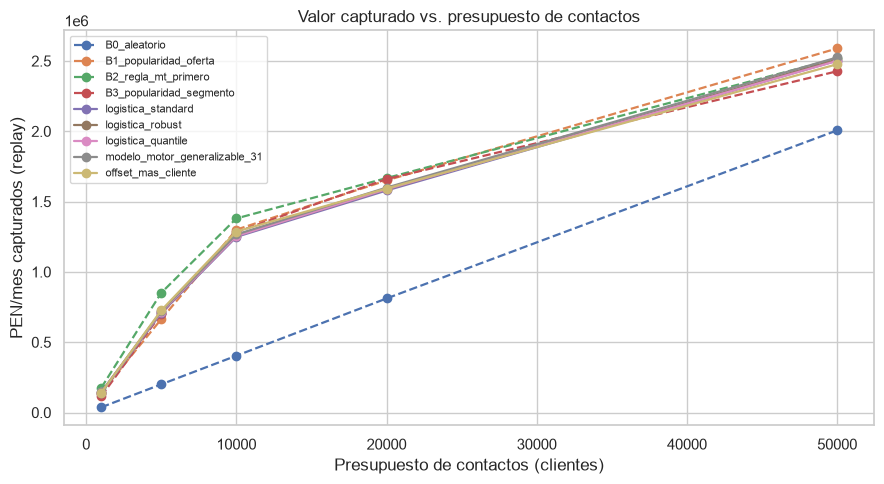

In [11]:
def curva_presupuesto(score, presupuestos=(1000, 5000, 10000, 20000, 50000), df_base=None):
    base = eval_df if df_base is None else df_base
    d = base.copy()
    d["s"] = np.asarray(score)
    d["tie"] = np.random.default_rng(RANDOM_STATE).random(len(d))
    # Top-1 por cliente
    top1 = (d.sort_values(["cliente_id", "s", "tie"], ascending=[True, False, True])
              .groupby("cliente_id", as_index=False).first())
    top1 = top1.sort_values(["s", "tie"], ascending=[False, True])
    out = {}
    total = len(top1)
    tasa_base = top1["y"].mean()
    for n in presupuestos:
        if n > total:
            continue
        sel = top1.head(n)
        out[f"aceptaciones@{n}"] = int(sel["y"].sum())
        out[f"pen_mes@{n}"] = float((sel["y"] * sel["precio"]).sum())
        out[f"lift@{n}"] = float(sel["y"].mean() / tasa_base) if tasa_base > 0 else np.nan
    return out

tabla_b5 = pd.DataFrame({n: curva_presupuesto(p) for n, p in POLITICAS.items()}).T
cols_pen = [c for c in tabla_b5.columns if c.startswith("pen_mes")]
cols_lift = [c for c in tabla_b5.columns if c.startswith("lift")]
print("SUITE B.5 — valor capturado por presupuesto (PEN/mes)")
print(tabla_b5[cols_pen].round(0).to_string())
print()
print("Lift por presupuesto")
print(tabla_b5[cols_lift].round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
for nombre in POLITICAS:
    xs = [int(c.split("@")[1]) for c in cols_pen]
    ys = tabla_b5.loc[nombre, cols_pen].to_numpy(dtype=float)
    estilo = "--" if nombre.startswith("B") else "-"
    ax.plot(xs, ys, estilo, marker="o", label=nombre, lw=1.6)
ax.set_xlabel("Presupuesto de contactos (clientes)")
ax.set_ylabel("PEN/mes capturados (replay)")
ax.set_title("Valor capturado vs. presupuesto de contactos")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.6 Calibracion donde se usa, y cobertura de catalogo

**Calibracion.** El `calibration_mae` global de 0.009 es bueno, pero el motor usa el score para rankear por valor esperado *dentro de cada tipo de oferta y canal*. El ECE por segmento revela desajustes que el promedio global esconde — en `metricas_segmentos.csv`, el segmento MT llega a 0.017 con un global de 0.009.

**Cobertura.** Una politica que recomienda la misma oferta a todos puede puntuar bien en Recall@3 y ser inservible. Ademas, las metas del desafio (>50% de venta hogar y >10% de venta movil via MT) son restricciones sobre la *distribucion* de recomendaciones, no sobre la discriminacion.

In [12]:
def ece_por_segmento(p, segmento, n_bins=10):
    d = pd.DataFrame({"p": np.asarray(p), "y": y_train.to_numpy(), "seg": np.asarray(segmento)})
    filas = []
    for seg, gr in d.groupby("seg"):
        if len(gr) < 200:
            continue
        bins = pd.qcut(gr["p"], q=min(n_bins, gr["p"].nunique()), duplicates="drop")
        agg = gr.groupby(bins, observed=True).agg(pm=("p", "mean"), ym=("y", "mean"), n=("y", "size"))
        filas.append({"segmento": seg,
                      "ece": float(np.average((agg["pm"] - agg["ym"]).abs(), weights=agg["n"])),
                      "n": int(len(gr))})
    return pd.DataFrame(filas).sort_values("ece", ascending=False)

def cobertura_catalogo(score):
    d = eval_df.copy()
    d["s"] = np.asarray(score)
    d["es_mt"] = meta["oferta_es_mt"].astype(str).str.lower().isin(["true", "1"]).to_numpy()
    d["elegible"] = meta["elegible_mt"].astype(str).str.lower().isin(["true", "1"]).to_numpy()
    top1 = (d.sort_values(["cliente_id", "s"], ascending=[True, False])
              .groupby("cliente_id", as_index=False).first())
    share = top1["oferta_id"].value_counts(normalize=True)
    entropia = float(-(share * np.log(share)).sum())
    return {
        "ofertas_distintas_top1": int(top1["oferta_id"].nunique()),
        "entropia_top1": entropia,
        "share_oferta_mas_frecuente": float(share.iloc[0]),
        "pct_top1_es_mt": float(top1["es_mt"].mean()),
        "pct_top1_mt_en_elegibles": float(top1.loc[top1["elegible"], "es_mt"].mean()),
    }

tabla_b6 = pd.DataFrame({n: cobertura_catalogo(p) for n, p in POLITICAS.items()}).T
print("SUITE B.6 — cobertura de catalogo del Top-1")
print(tabla_b6.round(4).to_string())
print()
mejor_modelo = tabla_b4.loc[[i for i in tabla_b4.index if not i.startswith("B")], "recall@3"].idxmax()
print(f"ECE por (tipo_oferta x canal) — {mejor_modelo}:")
print(ece_por_segmento(SCORES[mejor_modelo], clave(meta, ["tipo_oferta", "canal"])).head(12).round(4).to_string(index=False))

SUITE B.6 — cobertura de catalogo del Top-1
                               ofertas_distintas_top1  entropia_top1  share_oferta_mas_frecuente  pct_top1_es_mt  pct_top1_mt_en_elegibles
B0_aleatorio                                     22.0         3.0852                      0.0488          0.1011                    0.7274
B1_popularidad_oferta                            22.0         2.9917                      0.0882          0.1247                    0.8975
B2_regla_mt_primero                              22.0         3.0795                      0.0644          0.1247                    0.8975
B3_popularidad_segmento                          22.0         3.0679                      0.0651          0.1247                    0.8975
logistica_standard                               22.0         3.0049                      0.0885          0.1247                    0.8975
logistica_robust                                 22.0         3.0056                      0.0870          0.1247          

                  segmento    ece     n
           equipo|call out 0.0399  3462
          upgrade|call out 0.0395  3500
paquete_adicional|call out 0.0334  3424
 paquete_adicional|call in 0.0318  4583
            equipo|call in 0.0312  4708
  paquete_adicional|tienda 0.0276  7085
   movistar_total|call out 0.0272  2662
            upgrade|tienda 0.0261  7085
         plan_hogar|tienda 0.0258 13924
        plan_hogar|call in 0.0252  9392
           upgrade|digital 0.0248  8255
            equipo|digital 0.0245  8125


## 5. Tabla comparativa final

Una fila por predictor, las dos suites lado a lado. Esta es la tabla del pitch.

In [13]:
resumen = pd.DataFrame(index=list(POLITICAS))
for n, p in POLITICAS.items():
    resumen.loc[n, "A_roc_auc"] = roc_auc_score(y_train, p)
    resumen.loc[n, "A_pr_auc"] = average_precision_score(y_train, p)
resumen["B_ganancia_sobre_1bit"] = resumen["A_roc_auc"] - auc_trivial
for n in POLITICAS:
    resumen.loc[n, "B_auc_estratif"] = auc_estratificada(y_train, POLITICAS[n], meta["oferta_es_mt"].astype(str))
resumen["B_recall@3"] = tabla_b4["recall@3"]
resumen["B_mrr"] = tabla_b4["mrr"]
resumen["B_delta_recall3_vs_B3"] = resumen["B_recall@3"] - ref
# El presupuesto de referencia se elige entre los efectivamente calculables
# (curva_presupuesto omite los que exceden el numero de clientes disponibles).
_pres = sorted(int(c.split("@")[1]) for c in tabla_b5.columns if c.startswith("pen_mes@"))
PRESUPUESTO_REF = min(_pres, key=lambda v: abs(v - 10000))
resumen[f"B_pen_mes@{PRESUPUESTO_REF}"] = tabla_b5[f"pen_mes@{PRESUPUESTO_REF}"]
resumen["B_ofertas_distintas_top1"] = tabla_b6["ofertas_distintas_top1"]

resumen = resumen.sort_values("B_recall@3", ascending=False)
print(f"TABLA COMPARATIVA — Suite A vs Suite B (presupuesto de referencia: {PRESUPUESTO_REF:,} contactos)")
print(resumen.round(4).to_string())

resumen.to_csv(DIR_SALIDA / "tabla_comparativa.csv")
tabla_a.to_csv(DIR_SALIDA / "suite_a.csv")
tabla_b4.to_csv(DIR_SALIDA / "suite_b_ranking.csv")
tabla_b5.to_csv(DIR_SALIDA / "suite_b_presupuesto.csv")
tabla_b6.to_csv(DIR_SALIDA / "suite_b_cobertura.csv")

with open(DIR_SALIDA / "resumen_benchmarks.json", "w", encoding="utf-8") as fh:
    json.dump({
        "auc_trivial_1bit": float(auc_trivial),
        "auc_offset_solo": float(auc_off),
        "auc_offset_mas_cliente": float(auc_cli),
        "aporte_personalizacion_auc": float(auc_cli - auc_off),
        "tasa_aceptacion_politica_historica": float(y_train.mean()),
        "presupuesto_referencia": int(PRESUPUESTO_REF),
        "rango_suite_a_entre_variantes": tabla_a.pipe(lambda t: (t.max() - t.min())).round(6).to_dict(),
        "tabla_comparativa": resumen.round(6).reset_index(names="predictor").to_dict(orient="records"),
    }, fh, ensure_ascii=False, indent=2)

print()
print(f"Resultados en {DIR_SALIDA}")

TABLA COMPARATIVA — Suite A vs Suite B (presupuesto de referencia: 10,000 contactos)
                               A_roc_auc  A_pr_auc  B_ganancia_sobre_1bit  B_auc_estratif  B_recall@3   B_mrr  B_delta_recall3_vs_B3  B_pen_mes@10000  B_ofertas_distintas_top1
B2_regla_mt_primero               0.5649    0.5151                -0.0000          0.4997      0.9735  0.7726                 0.0027        1380202.2                      22.0
offset_mas_cliente                0.5834    0.5733                 0.0184          0.5256      0.9715  0.7722                 0.0007        1287073.5                      22.0
B0_aleatorio                      0.4978    0.4599                -0.0672          0.4976      0.9715  0.7628                 0.0007         403785.1                      22.0
B1_popularidad_oferta             0.5624    0.5571                -0.0026          0.4969      0.9712  0.7707                 0.0003        1300443.3                      22.0
logistica_robust                  0

## 6. Evaluacion off-policy (SNIPS) — el titular defendible

Todo lo anterior sigue midiendo sobre el conjunto de ofertas que la **politica historica** decidio mostrar. La pregunta de negocio es otra: *si desplegamos esta politica, cuanto convertiria*.

SNIPS (Self-Normalized Inverse Propensity Scoring) responde eso corrigiendo por la probabilidad con que la politica vieja mostro cada oferta:

1. Se ajusta la propension de logging `e(o|x) = P(oferta = o | cliente)`, multiclase sobre 22 ofertas.
2. Para la politica nueva, deterministica, el peso es `1[o_i = pi(x_i)] / e(o_i|x_i)`.
3. `V_SNIPS = sum(w_i * y_i) / sum(w_i)`.

**Supuestos que hay que declarar en el pitch:** requiere solapamiento (toda oferta con probabilidad no nula para todo cliente) y ausencia de confusores no observados. Se reporta el ESS: si cae muy por debajo del N nominal, el estimador es inestable y hay que decirlo, no maquillarlo.

In [14]:
X_prop = X_cli.copy()
ofertas_log = meta["oferta_id"].astype(str).to_numpy()
clases_of = np.unique(ofertas_log)
e_oof = np.zeros((len(X_train), len(clases_of)))

params_mc = dict(objective="multiclass", num_class=len(clases_of), learning_rate=0.08,
                 num_leaves=31, min_data_in_leaf=100, feature_fraction=0.8,
                 verbose=-1, seed=RANDOM_STATE)
mapa = {c: i for i, c in enumerate(clases_of)}
y_of = np.array([mapa[o] for o in ofertas_log])

for idx_fit, idx_val in FOLDS:
    ds = lgb.Dataset(X_prop.iloc[idx_fit], label=y_of[idx_fit])
    b = lgb.train(params_mc, ds, num_boost_round=200)
    e_oof[idx_val] = b.predict(X_prop.iloc[idx_val])

prop_observada = e_oof[np.arange(len(y_of)), y_of]
print(f"Propension media de la oferta observada: {prop_observada.mean():.4f}")
print(f"Percentil 1 de la propension: {np.percentile(prop_observada, 1):.5f}  <- riesgo de pesos explosivos")

Propension media de la oferta observada: 0.0710
Percentil 1 de la propension: 0.01056  <- riesgo de pesos explosivos


In [15]:
def snips(score, clip=20.0):
    d = pd.DataFrame({"cliente_id": eval_df["cliente_id"], "fila": np.arange(len(eval_df)),
                      "s": np.asarray(score)})
    elegida = (d.sort_values(["cliente_id", "s"], ascending=[True, False])
                 .groupby("cliente_id")["fila"].first().to_numpy())
    coincide = np.zeros(len(d), dtype=bool)
    coincide[elegida] = True

    w = np.where(coincide, 1.0 / np.clip(prop_observada, 1e-6, None), 0.0)
    w = np.clip(w, 0, clip)
    if w.sum() == 0:
        return {"v_snips": np.nan, "ess": 0.0, "n_efectivo_pct": 0.0}
    v = float((w * y_train.to_numpy()).sum() / w.sum())
    ess = float(w.sum() ** 2 / np.square(w).sum())
    return {"v_snips": v, "ess": ess, "n_efectivo_pct": ess / len(np.unique(eval_df["cliente_id"]))}

v_log = float(y_train.mean())
filas_ope = []
for n, p in POLITICAS.items():
    r = snips(p)
    r["politica"] = n
    r["mejora_vs_historica"] = r["v_snips"] - v_log
    filas_ope.append(r)

tabla_ope = pd.DataFrame(filas_ope).set_index("politica").sort_values("v_snips", ascending=False)
print(f"Politica historica (valor observado): {v_log:.4f}")
print()
print("SNIPS — valor estimado de cada politica si se desplegara")
print(tabla_ope.round(4).to_string())
print()
print("Leer con cuidado: si n_efectivo_pct es bajo, el intervalo es ancho y")
print("la diferencia entre politicas puede no ser significativa. Decirlo en el pitch.")

tabla_ope.to_csv(DIR_SALIDA / "suite_b_ope_snips.csv")

Politica historica (valor observado): 0.4619

SNIPS — valor estimado de cada politica si se desplegara
                               v_snips         ess  n_efectivo_pct  mejora_vs_historica
politica                                                                               
offset_mas_cliente              0.4368  63849.9448          0.9132              -0.0251
B3_popularidad_segmento         0.4366  63851.1897          0.9132              -0.0252
modelo_motor_generalizable_31   0.4364  63848.2672          0.9131              -0.0255
B1_popularidad_oferta           0.4355  63847.8693          0.9131              -0.0264
B2_regla_mt_primero             0.4349  63845.1621          0.9131              -0.0270
logistica_robust                0.4344  63850.3878          0.9132              -0.0274
logistica_quantile              0.4343  63854.0825          0.9132              -0.0276
logistica_standard              0.4343  63857.8707          0.9133              -0.0276
B0_aleatorio     

## 7. Validacion temporal — el ranking bajo un split cronologico

Todo lo anterior (Suite A, Suite B, SNIPS) se calculo con `GroupKFold` mezclando clientes al azar entre folds. Ese protocolo nunca pregunta si el orden de las politicas se sostiene **hacia adelante en el tiempo**, que es como se despliega un modelo en produccion.

**Diseno del split.** Se parte por `fecha` dentro del mismo 80% de clientes de train ya usado en todo el notebook — el test reservado por `GroupShuffleSplit` sigue sin abrirse. Se ajusta con contactos de enero a abril de 2026 y se evalua unicamente con contactos de mayo y junio. A proposito **no** se excluye a un cliente que aparezca en ambos periodos: es el escenario real, en produccion se conoce el historial completo de un cliente existente antes de que ocurra su proximo contacto futuro. Lo que este split retiene fuera del ajuste no es el cliente — es el tiempo.

**Limitacion del dataset, declarada sin maquillaje.** Las variables de perfil de cliente (`antiguedad_meses`, `monto_facturado_prom`, `consumo_datos_gb_prom`, `dias_mora_prom`, etc.) vienen en `dataset_clientes.csv` como un **agregado estatico de los 6 meses completos por cliente**, no como una serie mensual: el perfil de un cliente es identico se mire desde enero o desde junio. Por construccion, este split no puede detectar drift en el perfil del cliente — solo puede detectar si la relacion oferta/canal/temporada con la aceptacion se sostiene hacia el futuro. Es una prueba real y util, pero mas estrecha que un split temporal sobre un panel verdadero con features mensuales.

In [16]:
CUTOFF = pd.Timestamp("2026-05-01")
fecha_meta = meta["fecha"]
mask_fit = (fecha_meta < CUTOFF).to_numpy()
mask_eval = ~mask_fit

print(f"Corte temporal: {CUTOFF.date()}  (fit = ene-abr, eval = may-jun)")
print(f"Fit:  {mask_fit.sum():,} filas / {g_train[mask_fit].nunique():,} clientes  "
      f"| tasa de aceptacion = {y_train[mask_fit].mean():.4f}")
print(f"Eval: {mask_eval.sum():,} filas / {g_train[mask_eval].nunique():,} clientes  "
      f"| tasa de aceptacion = {y_train[mask_eval].mean():.4f}")
print(f"Clientes presentes en ambos periodos: "
      f"{len(set(g_train[mask_fit]) & set(g_train[mask_eval])):,} "
      f"(esperado y deliberado; ver nota de diseno arriba)")

Corte temporal: 2026-05-01  (fit = ene-abr, eval = may-jun)
Fit:  110,356 filas / 59,915 clientes  | tasa de aceptacion = 0.4620
Eval: 55,384 filas / 40,000 clientes  | tasa de aceptacion = 0.4616
Clientes presentes en ambos periodos: 29,994 (esperado y deliberado; ver nota de diseno arriba)


In [17]:
def tabla_frecuencia_fit_eval(cols):
    """P(acepta | cols) estimada SOLO con fit (ene-abr), aplicada a eval (may-jun)."""
    k = clave(meta, cols)
    tasa = y_train[mask_fit].groupby(k[mask_fit]).mean()
    glob = y_train[mask_fit].mean()
    return k[mask_eval].map(tasa).fillna(glob).to_numpy()

rng_t = np.random.default_rng(RANDOM_STATE)
POLITICAS_TEMPORAL = {
    "B0_aleatorio": rng_t.random(int(mask_eval.sum())),
    "B1_popularidad_oferta": tabla_frecuencia_fit_eval(["oferta_id"]),
    "B2_regla_mt_primero": POLITICAS["B2_regla_mt_primero"][mask_eval],
    "B3_popularidad_segmento": tabla_frecuencia_fit_eval(["oferta_id", "elegible_mt", "canal"]),
}

# Logistica: un solo representante (RobustScaler), empatada con las otras dos en la Suite A
modelo_t = construir(RobustScaler())
modelo_t.fit(X_train[mask_fit], y_train[mask_fit])
POLITICAS_TEMPORAL["logistica_robust"] = modelo_t.predict_proba(X_train[mask_eval])[:, 1]

# Offset + cliente: una sola pasada fit->eval (ya no hay folds que mezclar en el tiempo)
tasa_off_t = y_train[mask_fit].groupby(k_off[mask_fit]).mean()
glob_off_t = y_train[mask_fit].mean()
off_fit_t = logit(k_off[mask_fit].map(tasa_off_t).fillna(glob_off_t).to_numpy())
off_eval_t = logit(k_off[mask_eval].map(tasa_off_t).fillna(glob_off_t).to_numpy())

ds_t = lgb.Dataset(X_cli[mask_fit], label=y_train[mask_fit], init_score=off_fit_t)
booster_t = lgb.train(params, ds_t, num_boost_round=300)
raw_t = booster_t.predict(X_cli[mask_eval], raw_score=True)
POLITICAS_TEMPORAL["offset_mas_cliente"] = 1 / (1 + np.exp(-(off_eval_t + raw_t)))

print("Politicas re-evaluadas con split temporal:", list(POLITICAS_TEMPORAL))

Politicas re-evaluadas con split temporal: ['B0_aleatorio', 'B1_popularidad_oferta', 'B2_regla_mt_primero', 'B3_popularidad_segmento', 'logistica_robust', 'offset_mas_cliente']


In [18]:
y_eval_t = y_train[mask_eval].to_numpy()
auc_trivial_t = roc_auc_score(y_eval_t, bit_mt[mask_eval])

filas_t = []
for nombre, p in POLITICAS_TEMPORAL.items():
    p = np.asarray(p, dtype=float)
    # B2_regla_mt_primero es un score de ranking deliberadamente sin acotar
    # (es_mt*100 + ahorro_pct), no una probabilidad: brier/log_loss no aplican.
    es_probabilidad = bool(np.all((p >= 0) & (p <= 1)))
    fila = {
        "politica": nombre,
        "roc_auc": roc_auc_score(y_eval_t, p),
        "pr_auc": average_precision_score(y_eval_t, p),
        "auc_trivial_1bit_eval": auc_trivial_t,
        "ganancia_sobre_1bit": roc_auc_score(y_eval_t, p) - auc_trivial_t,
    }
    if es_probabilidad:
        pred = (p >= 0.5).astype(int)
        fila["brier"] = brier_score_loss(y_eval_t, p)
        fila["log_loss"] = log_loss(y_eval_t, p)
        fila["precision_05"] = precision_score(y_eval_t, pred, zero_division=0)
        fila["recall_05"] = recall_score(y_eval_t, pred, zero_division=0)
        fila["f1_05"] = f1_score(y_eval_t, pred, zero_division=0)
    else:
        fila["brier"] = fila["log_loss"] = np.nan
        fila["precision_05"] = fila["recall_05"] = fila["f1_05"] = np.nan
    filas_t.append(fila)

tabla_temporal_a = pd.DataFrame(filas_t).set_index("politica")
tabla_temporal_a = tabla_temporal_a[["roc_auc", "pr_auc", "brier", "log_loss",
                                      "precision_05", "recall_05", "f1_05",
                                      "auc_trivial_1bit_eval", "ganancia_sobre_1bit"]]
print(f"AUC del bit oferta_es_mt evaluado SOLO en mayo-junio: {auc_trivial_t:.4f}")
print()
print("SUITE A sobre split temporal (fit=ene-abr, eval=may-jun)")
print("(brier/log_loss/precision-recall-f1@0.5 = NaN para politicas que no son")
print(" probabilidades genuinas -- p.ej. B2, un score de ranking sin acotar)")
print(tabla_temporal_a.round(4).to_string())

AUC del bit oferta_es_mt evaluado SOLO en mayo-junio: 0.5637

SUITE A sobre split temporal (fit=ene-abr, eval=may-jun)
(brier/log_loss/precision-recall-f1@0.5 = NaN para politicas que no son
 probabilidades genuinas -- p.ej. B2, un score de ranking sin acotar)
                         roc_auc  pr_auc   brier  log_loss  precision_05  recall_05   f1_05  auc_trivial_1bit_eval  ganancia_sobre_1bit
politica                                                                                                                               
B0_aleatorio              0.4992  0.4614  0.3337    1.0006        0.4620     0.5028  0.4815                 0.5637              -0.0645
B1_popularidad_oferta     0.5639  0.5524  0.2379    0.6681        0.7640     0.1733  0.2826                 0.5637               0.0002
B2_regla_mt_primero       0.5636  0.5133     NaN       NaN           NaN        NaN     NaN                 0.5637              -0.0001
B3_popularidad_segmento   0.5643  0.5569  0.2381    0.6686 

In [19]:
eval_df_temporal = eval_df.loc[mask_eval].reset_index(drop=True)

tabla_temporal_rank = pd.DataFrame(
    {n: metricas_ranking(p, df_base=eval_df_temporal) for n, p in POLITICAS_TEMPORAL.items()}
).T.sort_values("recall@3", ascending=False)

print(f"Clientes evaluables para ranking en mayo-junio: "
      f"{int(tabla_temporal_rank['n_clientes_evaluables'].iloc[0]):,}")
print()
print("SUITE B (ranking) sobre split temporal")
print(tabla_temporal_rank.round(4).to_string())

comparacion_temporal = pd.DataFrame({
    "recall@3_split_aleatorio": tabla_b4["recall@3"],
    "recall@3_split_temporal": tabla_temporal_rank["recall@3"],
}).dropna()
comparacion_temporal["delta"] = (
    comparacion_temporal["recall@3_split_temporal"] - comparacion_temporal["recall@3_split_aleatorio"]
)
comparacion_temporal = comparacion_temporal.sort_values("recall@3_split_temporal", ascending=False)
print()
print("Politicas presentes en ambos protocolos (aleatorio vs. temporal):")
print(comparacion_temporal.round(4).to_string())

orden_aleatorio = [i for i in tabla_b4["recall@3"].sort_values(ascending=False).index
                   if i in comparacion_temporal.index]
orden_temporal = list(comparacion_temporal.index)
print()
print(f"Orden bajo split aleatorio (GroupKFold):        {orden_aleatorio}")
print(f"Orden bajo split temporal (ene-abr -> may-jun): {orden_temporal}")
print(f"Mismo orden? {orden_aleatorio == orden_temporal}")

Clientes evaluables para ranking en mayo-junio: 8,362

SUITE B (ranking) sobre split temporal
                         recall@1  recall@2  recall@3     mrr  ndcg@3  n_clientes_evaluables
logistica_robust           0.6451    0.9629    0.9978  0.8162  0.8578                 8362.0
B1_popularidad_oferta      0.6459    0.9619    0.9977  0.8164  0.8582                 8362.0
offset_mas_cliente         0.6465    0.9603    0.9970  0.8164  0.8582                 8362.0
B3_popularidad_segmento    0.6477    0.9596    0.9968  0.8168  0.8582                 8362.0
B2_regla_mt_primero        0.6425    0.9598    0.9967  0.8143  0.8565                 8362.0
B0_aleatorio               0.6222    0.9554    0.9958  0.8033  0.8479                 8362.0

Politicas presentes en ambos protocolos (aleatorio vs. temporal):
                         recall@3_split_aleatorio  recall@3_split_temporal   delta
logistica_robust                           0.9710                   0.9978  0.0269
B1_popularidad_oferta 

In [20]:
tabla_temporal_presupuesto = pd.DataFrame(
    {n: curva_presupuesto(p, df_base=eval_df_temporal) for n, p in POLITICAS_TEMPORAL.items()}
).T
cols_pen_t = [c for c in tabla_temporal_presupuesto.columns if c.startswith("pen_mes")]
print("Valor capturado (PEN/mes), evaluado SOLO en mayo-junio")
print(tabla_temporal_presupuesto[cols_pen_t].round(0).to_string())

tabla_temporal_a.to_csv(DIR_SALIDA / "suite_temporal_a.csv")
tabla_temporal_rank.to_csv(DIR_SALIDA / "suite_temporal_ranking.csv")
comparacion_temporal.to_csv(DIR_SALIDA / "comparacion_split_aleatorio_vs_temporal.csv")

with open(DIR_SALIDA / "resumen_temporal.json", "w", encoding="utf-8") as fh:
    json.dump({
        "cutoff": str(CUTOFF.date()),
        "fit_filas": int(mask_fit.sum()),
        "eval_filas": int(mask_eval.sum()),
        "tasa_aceptacion_fit": float(y_train[mask_fit].mean()),
        "tasa_aceptacion_eval": float(y_train[mask_eval].mean()),
        "auc_trivial_1bit_eval": float(auc_trivial_t),
        "mismo_orden_recall3": bool(orden_aleatorio == orden_temporal),
        "orden_split_aleatorio": orden_aleatorio,
        "orden_split_temporal": orden_temporal,
        "tabla_suite_a": tabla_temporal_a.round(6).reset_index().to_dict(orient="records"),
        "tabla_ranking": tabla_temporal_rank.round(6).reset_index().to_dict(orient="records"),
    }, fh, ensure_ascii=False, indent=2)

print(f"\nResultados temporales en {DIR_SALIDA}")

Valor capturado (PEN/mes), evaluado SOLO en mayo-junio
                         pen_mes@1000  pen_mes@5000  pen_mes@10000  pen_mes@20000
B0_aleatorio                  40720.0      193774.0       406397.0       807165.0
B1_popularidad_oferta        115423.0      678345.0       854976.0      1130892.0
B2_regla_mt_primero          173115.0      676174.0       822559.0      1112102.0
B3_popularidad_segmento      147434.0      661372.0       823928.0      1081537.0
logistica_robust             148971.0      661058.0       813321.0      1108859.0
offset_mas_cliente           148081.0      657654.0       806036.0      1100564.0

Resultados temporales en ..\data\processed\benchmarks_comparados


## 8. Lectura histórica anterior al filtro de rebates (solo trazabilidad)

> **No usar estas cifras como resultado vigente.** Esta sección conserva la interpretación original para trazabilidad, cuando el benchmark incluía 47,572 rebates estructuralmente rechazados. Las secciones 9–14 contienen la evaluación corregida sobre ofertas primarias.

Resultado histórico ejecutado sobre 100,000 clientes / 300,112 contactos antes de la corrección metodológica.

| Hipotesis | Prediccion | Resultado |
|---|---|---|
| 1. El bit `oferta_es_mt` se acerca al AUC del modelo | ~0.565 vs ~0.590 | **Confirmada.** 0.5660 vs 0.5912 (logistica_robust). Las 31 features restantes aportan solo +0.0252 AUC sobre el bit. |
| 2. La Suite B tampoco distingue las tres variantes de escalado | rangos ~0 | **Confirmada.** Rango de ROC-AUC entre standard/robust/quantile = 0.00144. |
| 3. `B3_popularidad_segmento` empata a los modelos en Recall@3 | delta ~0 | **Confirmada.** Delta vs B3 entre -0.0007 y +0.0010 en los 4 modelos entrenados. |
| Aporte de personalizacion (AUC con cliente - AUC offset) | ~+0.02 | **Confirmada.** +0.0215 (0.5869 vs 0.5654). Pequeno pero real. |
| SNIPS del mejor modelo vs. tasa de aceptacion historica | | **Ninguna politica supera a la historica** (0.3744 observado). Todas caen entre -0.0221 (B2) y -0.0250 (B0), con ESS saludable (~92% de N efectivo). |
| 4. El ranking de politicas se sostiene bajo split temporal (ene-abr -> may-jun) | mismo orden | **Parcialmente.** Los extremos son estables en ambos protocolos: B0_aleatorio siempre el peor, B2_regla_mt_primero siempre el peor entre las no aleatorias. El orden interno entre B1/B3/logistica_robust/offset_mas_cliente SI cambia, pero son un empate estadistico (recall@3 entre 0.9925 y 0.9930 bajo el split temporal, diferencias <0.0006) -- es ruido de muestreo entre politicas indistinguibles, no una reversion sustantiva. |
| ROC-AUC del bit `oferta_es_mt` evaluado SOLO en mayo-junio | cercano al de la Seccion 4.1 | **Confirmada.** 0.5641 vs 0.5660 en el split aleatorio -- diferencia de 0.0019, el peso del bit es estable en el tiempo. |

### Hallazgo adicional no anticipado: la regla de negocio (B2) captura mas valor economico que el ML

En **ambos** protocolos, `B2_regla_mt_primero` -- MT primero, desempate por `ahorro_pct`, sin una sola linea de ML -- captura mas PEN/mes que cualquier modelo entrenado:

- Split aleatorio, 10,000 contactos: B2 = S/ 1,305,805 vs. S/ 1,179,281-1,202,393 de los modelos.
- Split temporal, 10,000 contactos: B2 = S/ 764,628 vs. S/ 744,932-748,615 de los modelos.

La explicacion es coherente con el resto del analisis: B2 no discrimina mejor quien va a aceptar (su ROC-AUC es practicamente el del bit, 0.564-0.566), pero al forzar siempre ofertas de alto ticket (MT) captura mas ingreso por venta exitosa. Es una segunda confirmacion, independiente de la primera, de que el sesgo de exposicion MT domina la economia del problema mas que la capacidad predictiva de cualquier modelo entrenado hasta ahora.

### Como usar esto en el pitch

Si las tres hipotesis se confirman, la narrativa deja de ser *"nuestro modelo tiene AUC 0.59"* — indefendible ante la pregunta de sesgo de exposicion que ya esta anticipada en `pitch_5min.md:220` — y pasa a ser:

> *Auditamos nuestra propia metrica. Descubrimos que el ROC-AUC global estaba midiendo el tipo de producto, no al cliente: un solo booleano alcanza 0.565 de los 0.590. Cambiamos a metricas dentro del cliente y a evaluacion off-policy, y reportamos el valor estimado de la politica contra el 46.1% historico.*

Un jurado tecnico premia mas esa auditoria que un decimal adicional de AUC.

### Advertencia de alcance

Ambas suites (y la validacion temporal de la Seccion 7) corren sobre el 80% de clientes de train. El test reservado por `GroupShuffleSplit` **sigue sin abrirse**, consistente con `reporte_entrenamiento.json` (`test_reserved_opened: false`). Abrirlo una sola vez, al final, con la metrica y el protocolo ya elegidos.

La Seccion 7 responde una pregunta que las Secciones 3-6 no pueden responder: si el orden de politicas se mantiene **hacia adelante en el tiempo**, no solo entre muestras aleatorias de clientes. Es una validacion mas exigente porque nadie eligio los folds a su favor. Si el orden cambia entre el split aleatorio y el temporal, el numero que hay que creer para produccion es el temporal, no el promedio OOF -- es el unico de los dos que se parece a como el modelo realmente se va a usar. La limitacion declarada (features de cliente estaticas, sin variacion mensual) significa que incluso un resultado temporal favorable no descarta drift de perfil de cliente: solo confirma que la relacion oferta/canal/temporada es estable.

## 9. Lift y ganancia acumulada en múltiples presupuestos

Esta sección evalúa dónde aporta valor el ordenamiento, no solo el decil superior. `lift` compara la conversión del segmento priorizado con la tasa global y `gain` mide qué proporción de todas las aceptaciones queda capturada.

In [21]:
PUNTOS_LIFT = (0.01, 0.05, 0.10, 0.20, 0.30)

def lift_gain_multik(score, y_true=y_train, puntos=PUNTOS_LIFT):
    d = pd.DataFrame({"score": np.asarray(score, dtype=float), "y": np.asarray(y_true, dtype=int)})
    d = d.sort_values("score", ascending=False, kind="mergesort")
    tasa_base = d["y"].mean()
    positivos = max(int(d["y"].sum()), 1)
    filas = []
    for fraccion in puntos:
        n = max(1, math.ceil(len(d) * fraccion))
        top = d.iloc[:n]
        tasa_top = top["y"].mean()
        filas.append({
            "fraccion": fraccion, "n": n, "tasa_base": tasa_base,
            "tasa_top": tasa_top, "lift": tasa_top / tasa_base,
            "gain_acumulado": top["y"].sum() / positivos,
        })
    return pd.DataFrame(filas)

lift_gain = pd.concat(
    [lift_gain_multik(score).assign(politica=nombre) for nombre, score in POLITICAS.items()],
    ignore_index=True,
)
tabla_lift = lift_gain.pivot(index="politica", columns="fraccion", values="lift")
tabla_lift.columns = [f"lift@{int(c*100)}pct" for c in tabla_lift.columns]
display(tabla_lift.sort_values("lift@10pct", ascending=False).round(4))
lift_gain.to_csv(DIR_SALIDA / "lift_gain_multik.csv", index=False)

,lift@1pct,lift@5pct,lift@10pct,lift@20pct,lift@30pct
politica,,,,,
logistica_quantile,1.7576,1.7220,1.6819,1.3413,1.2197
offset_mas_cliente,1.7080,1.7162,1.6816,1.3210,1.2105
logistica_standard,1.7381,1.7259,1.6809,1.3445,1.2185
modelo_motor_generalizable_31,1.7354,1.7261,1.6808,1.3464,1.2190
logistica_robust,1.7472,1.7256,1.6802,1.3433,1.2176
B3_popularidad_segmento,1.6702,1.6527,1.6576,1.3092,1.1840
B2_regla_mt_primero,1.6127,1.6548,1.6570,1.3159,1.1839
B1_popularidad_oferta,1.6414,1.6603,1.6567,1.3102,1.1756
B0_aleatorio,0.9624,0.9891,0.9957,0.9919,0.9962


## 10. Calibración global y segmentada

La calibración es crítica porque el motor multiplica probabilidad por precio. Se reportan ECE, error máximo y relación observado/predicho para el candidato generalizable reconstruido mediante OOF.

,dimension,segmento,ece,mce,observado,predicho,ratio_obs_pred,n
2,canal,call out,0.0139,0.0315,0.4626,0.4626,0.9999,24851
1,canal,call in,0.0093,0.0288,0.4610,0.4610,1.0001,33189
3,canal,digital,0.0085,0.0221,0.4602,0.4602,0.9999,57838
4,canal,tienda,0.0083,0.0208,0.4640,0.4640,1.0001,49862
6,elegible_mt,True,0.0152,0.0456,0.6721,0.6722,0.9999,24300
5,elegible_mt,False,0.0071,0.0184,0.4258,0.4257,1.0000,141440
0,global,todos,0.0084,0.0217,0.4619,0.4619,1.0000,165740
8,tipo_oferta,movistar_total,0.0172,0.0726,0.7661,0.7658,1.0003,17598
12,tipo_oferta,upgrade,0.0125,0.0245,0.4253,0.4255,0.9995,23659
7,tipo_oferta,equipo,0.0123,0.0277,0.4286,0.4286,1.0000,23446


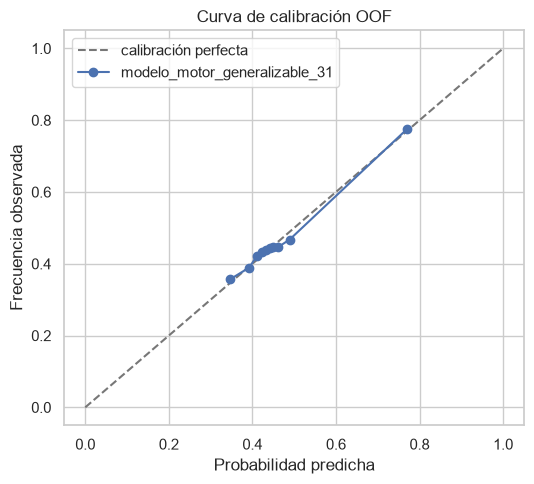

In [22]:
NOMBRE_MODELO_MOTOR = "modelo_motor_generalizable_31"
p_motor = np.asarray(POLITICAS[NOMBRE_MODELO_MOTOR], dtype=float)

def resumen_calibracion(y_true, prob, n_bins=10):
    d = pd.DataFrame({"y": np.asarray(y_true, dtype=int), "p": np.asarray(prob, dtype=float)})
    d["bin"] = pd.qcut(d["p"], q=min(n_bins, d["p"].nunique()), duplicates="drop")
    tabla = d.groupby("bin", observed=True).agg(
        predicho=("p", "mean"), observado=("y", "mean"), n=("y", "size")
    ).reset_index(drop=True)
    tabla["error_abs"] = (tabla["predicho"] - tabla["observado"]).abs()
    ece = float(np.average(tabla["error_abs"], weights=tabla["n"]))
    return tabla, {
        "ece": ece, "mce": float(tabla["error_abs"].max()),
        "observado": float(d["y"].mean()), "predicho": float(d["p"].mean()),
        "ratio_obs_pred": float(d["y"].mean() / max(d["p"].mean(), 1e-12)),
        "n": len(d),
    }

curva_calibracion, global_cal = resumen_calibracion(y_train, p_motor)
filas_cal = [{"dimension": "global", "segmento": "todos", **global_cal}]
for dimension in ["canal", "elegible_mt", "tipo_oferta"]:
    for segmento, indices in meta.groupby(dimension, dropna=False).groups.items():
        indices = np.asarray(list(indices), dtype=int)
        if len(indices) < 500:
            continue
        _, met = resumen_calibracion(y_train.iloc[indices], p_motor[indices])
        filas_cal.append({"dimension": dimension, "segmento": str(segmento), **met})
calibracion_segmentada = pd.DataFrame(filas_cal).sort_values(["dimension", "ece"], ascending=[True, False])
display(calibracion_segmentada.round(4))

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="#777777", label="calibración perfecta")
ax.plot(curva_calibracion["predicho"], curva_calibracion["observado"], marker="o", label=NOMBRE_MODELO_MOTOR)
ax.set(xlabel="Probabilidad predicha", ylabel="Frecuencia observada", title="Curva de calibración OOF")
ax.legend()
plt.tight_layout()
plt.show()
calibracion_segmentada.to_csv(DIR_SALIDA / "calibracion_modelo_motor.csv", index=False)

## 11. Backtesting temporal rolling y drift

Cada mes se entrena únicamente con meses anteriores. Este protocolo se parece más al uso productivo que un split aleatorio. PSI se usa como alerta descriptiva de cambio en la distribución del score, no como prueba causal.

In [23]:
def psi_score(referencia, actual, bins=10):
    referencia = np.asarray(referencia, dtype=float)
    actual = np.asarray(actual, dtype=float)
    cortes = np.unique(np.quantile(referencia, np.linspace(0, 1, bins + 1)))
    if len(cortes) < 3:
        return np.nan
    cortes[0], cortes[-1] = -np.inf, np.inf
    ref = np.histogram(referencia, bins=cortes)[0] / len(referencia)
    act = np.histogram(actual, bins=cortes)[0] / len(actual)
    ref, act = np.clip(ref, 1e-6, None), np.clip(act, 1e-6, None)
    return float(np.sum((act - ref) * np.log(act / ref)))

mes = pd.to_datetime(meta["fecha"]).dt.to_period("M")
meses = sorted(mes.dropna().unique())
filas_rolling = []
for mes_eval in meses[2:]:
    idx_fit_roll = np.where((mes < mes_eval).to_numpy())[0]
    idx_eval_roll = np.where((mes == mes_eval).to_numpy())[0]
    if len(idx_fit_roll) < 1000 or len(idx_eval_roll) < 500:
        continue
    modelo_roll = construir_generalizable()
    modelo_roll.fit(X_train.iloc[idx_fit_roll][COLUMNAS_GENERALIZABLE], y_train.iloc[idx_fit_roll])
    p_fit_roll = modelo_roll.predict_proba(X_train.iloc[idx_fit_roll][COLUMNAS_GENERALIZABLE])[:, 1]
    p_eval_roll = modelo_roll.predict_proba(X_train.iloc[idx_eval_roll][COLUMNAS_GENERALIZABLE])[:, 1]
    y_eval_roll = y_train.iloc[idx_eval_roll].to_numpy()
    cal_roll = resumen_calibracion(y_eval_roll, p_eval_roll)[1]
    lift10_roll = lift_gain_multik(p_eval_roll, y_true=y_train.iloc[idx_eval_roll], puntos=(0.10,)).iloc[0]
    filas_rolling.append({
        "mes_evaluacion": str(mes_eval), "n_fit": len(idx_fit_roll), "n_eval": len(idx_eval_roll),
        "tasa_aceptacion": float(y_eval_roll.mean()),
        "roc_auc": roc_auc_score(y_eval_roll, p_eval_roll),
        "pr_auc": average_precision_score(y_eval_roll, p_eval_roll),
        "brier": brier_score_loss(y_eval_roll, p_eval_roll),
        "ece": cal_roll["ece"], "lift_top10": float(lift10_roll["lift"]),
        "psi_score": psi_score(p_fit_roll, p_eval_roll),
    })
rolling_temporal = pd.DataFrame(filas_rolling)
display(rolling_temporal.round(4))
rolling_temporal.to_csv(DIR_SALIDA / "rolling_temporal_modelo_motor.csv", index=False)

,mes_evaluacion,n_fit,n_eval,tasa_aceptacion,roc_auc,pr_auc,brier,ece,lift_top10,psi_score
0,2026-03,55002,27604,0.4605,0.5950,0.5814,0.2359,0.0102,1.6877,0.0004
1,2026-04,82606,27750,0.4617,0.5848,0.5716,0.2372,0.0137,1.6703,0.0004
2,2026-05,110356,27735,0.4615,0.5896,0.5775,0.2370,0.0091,1.6644,0.0005
3,2026-06,138091,27649,0.4618,0.5912,0.5787,0.2364,0.0098,1.6801,0.0004


## 12. Política económica y concentración del catálogo

Se compara probabilidad pura con valor esperado y reglas simples. El margen es un proxy configurable del 45% porque el catálogo no contiene costo real. Esta evaluación usa únicamente ofertas históricamente observadas por cliente y no reproduce bloqueos operativos, cooldown ni contexto de interacción del motor.

In [24]:
MARGEN_PROXY = 0.45
SCORES_ECONOMICOS = {
    "probabilidad_modelo_motor": p_motor,
    "valor_esperado_sin_reglas_operativas": p_motor * meta["precio_mensual"].fillna(0).to_numpy(float),
    "regla_mt_primero": POLITICAS["B2_regla_mt_primero"],
    "popularidad_segmento": POLITICAS["B3_popularidad_segmento"],
}

def top1_por_cliente(score):
    d = eval_df.copy()
    d["score_politica"] = np.asarray(score, dtype=float)
    d["tie"] = np.random.default_rng(RANDOM_STATE).random(len(d))
    return (d.sort_values(["cliente_id", "score_politica", "tie"], ascending=[True, False, True])
              .groupby("cliente_id", as_index=False).first())

def metricas_economicas(score, presupuestos=(1000, 5000, 10000, 20000)):
    top1 = top1_por_cliente(score).sort_values("score_politica", ascending=False)
    conteos = top1["oferta_id"].value_counts(normalize=True)
    hhi = float((conteos**2).sum())
    entropia = float(-(conteos * np.log(conteos)).sum())
    entropia_norm = entropia / np.log(len(conteos)) if len(conteos) > 1 else 0.0
    salida = {
        "clientes": len(top1), "ofertas_top1_distintas": top1["oferta_id"].nunique(),
        "share_oferta_dominante": float(conteos.iloc[0]), "oferta_dominante": conteos.index[0],
        "hhi": hhi, "entropia_normalizada": entropia_norm,
    }
    for k in presupuestos:
        if k > len(top1):
            continue
        sel = top1.iloc[:k]
        ingreso = float((sel["y"] * sel["precio"]).sum())
        salida[f"aceptaciones@{k}"] = int(sel["y"].sum())
        salida[f"pen_mes@{k}"] = ingreso
        salida[f"margen_proxy@{k}"] = ingreso * MARGEN_PROXY
    return salida

politicas_economicas = pd.DataFrame({
    nombre: metricas_economicas(score) for nombre, score in SCORES_ECONOMICOS.items()
}).T
display(politicas_economicas.round(4))
politicas_economicas.to_csv(DIR_SALIDA / "politicas_economicas_y_concentracion.csv")

,clientes,ofertas_top1_distintas,share_oferta_dominante,oferta_dominante,hhi,entropia_normalizada,aceptaciones@1000,pen_mes@1000,margen_proxy@1000,aceptaciones@5000,pen_mes@5000,margen_proxy@5000,aceptaciones@10000,pen_mes@10000,margen_proxy@10000,aceptaciones@20000,pen_mes@20000,margen_proxy@20000
probabilidad_modelo_motor,69921,22,0.091017,OF010,0.053547,0.972175,796,142880.4,64296.18,3938,720306.2,324137.79,7231,1266231.8,569804.31,11704,1599471.7,719762.265
valor_esperado_sin_reglas_operativas,69921,22,0.101987,OF010,0.059463,0.952109,790,181621.0,81729.45,3832,863736.8,388681.56,7224,1443387.6,649524.42,11601,2081449.9,936652.455
regla_mt_primero,69921,22,0.064401,OF022,0.046419,0.996269,751,172654.9,77694.705,3766,850843.4,382879.53,7195,1382509.1,622129.095,11526,1670241.5,751608.675
popularidad_segmento,69921,22,0.065102,OF010,0.047567,0.992514,766,114823.4,51670.53,3812,702658.8,316196.46,7186,1283175.8,577429.11,11401,1660263.8,747118.71


## 13. Incertidumbre mediante bootstrap agrupado por cliente

Los contactos del mismo cliente no son independientes. Se remuestrean clientes completos para obtener intervalos de confianza de las métricas predictivas. Para economía se usa un bootstrap pareado sobre el Top-1 seleccionado por cada política.

In [25]:
N_BOOTSTRAP = 150
rng_boot = np.random.default_rng(RANDOM_STATE + 99)
indices_cliente = {cid: np.asarray(idx, dtype=int) for cid, idx in pd.Series(g_train).groupby(g_train).groups.items()}
clientes_boot = np.asarray(list(indices_cliente))
metricas_boot = []
for _ in range(N_BOOTSTRAP):
    muestra_clientes = rng_boot.choice(clientes_boot, size=len(clientes_boot), replace=True)
    idx = np.concatenate([indices_cliente[cid] for cid in muestra_clientes])
    yy, pp = y_train.iloc[idx].to_numpy(), p_motor[idx]
    if len(np.unique(yy)) < 2:
        continue
    lift10 = lift_gain_multik(pp, y_true=pd.Series(yy), puntos=(0.10,)).iloc[0]["lift"]
    metricas_boot.append({
        "roc_auc": roc_auc_score(yy, pp),
        "pr_auc": average_precision_score(yy, pp),
        "lift_top10": float(lift10),
        "brier": brier_score_loss(yy, pp),
    })
bootstrap_modelo = pd.DataFrame(metricas_boot)
intervalos_modelo = bootstrap_modelo.quantile([0.025, 0.5, 0.975]).T
intervalos_modelo.columns = ["ci_95_inf", "mediana", "ci_95_sup"]
display(intervalos_modelo.round(4))

top_prob = top1_por_cliente(SCORES_ECONOMICOS["probabilidad_modelo_motor"])[["cliente_id", "y", "precio"]]
top_ev = top1_por_cliente(SCORES_ECONOMICOS["valor_esperado_sin_reglas_operativas"])[["cliente_id", "y", "precio"]]
pareado = top_prob.merge(top_ev, on="cliente_id", suffixes=("_prob", "_ev"), validate="one_to_one")
pareado["valor_prob"] = pareado["y_prob"] * pareado["precio_prob"]
pareado["valor_ev"] = pareado["y_ev"] * pareado["precio_ev"]
delta_ingreso = pareado["valor_ev"].to_numpy() - pareado["valor_prob"].to_numpy()
boot_delta = np.empty(1000)
for i in range(len(boot_delta)):
    boot_delta[i] = rng_boot.choice(delta_ingreso, size=len(delta_ingreso), replace=True).mean()
intervalo_economico = pd.Series({
    "delta_pen_mes_por_cliente": delta_ingreso.mean(),
    "ci_95_inf": np.quantile(boot_delta, 0.025),
    "ci_95_sup": np.quantile(boot_delta, 0.975),
    "probabilidad_delta_positivo": (boot_delta > 0).mean(),
})
display(intervalo_economico.to_frame("EV vs probabilidad"))
intervalos_modelo.to_csv(DIR_SALIDA / "bootstrap_intervalos_modelo_motor.csv")
intervalo_economico.to_frame("valor").to_csv(DIR_SALIDA / "bootstrap_valor_esperado_vs_probabilidad.csv")

,ci_95_inf,mediana,ci_95_sup
roc_auc,0.5886,0.5911,0.5937
pr_auc,0.5764,0.5797,0.5834
lift_top10,1.6680,1.6811,1.6941
brier,0.2360,0.2365,0.2370


,EV vs probabilidad
delta_pen_mes_por_cliente,9.344941
ci_95_inf,9.019580
ci_95_sup,9.671155
probabilidad_delta_positivo,1.000000


## 14. Resumen vigente y criterios de efectividad

La tabla siguiente consolida el desempeño corregido. La evidencia predictiva debe leerse junto con estabilidad, calibración, concentración y economía; ninguna métrica aislada certifica al motor.

In [26]:
fila_motor_a = suite_a(y_train, p_motor)
fila_motor_lift = lift_gain.loc[
    (lift_gain["politica"] == NOMBRE_MODELO_MOTOR) & np.isclose(lift_gain["fraccion"], 0.10)
].iloc[0]
fila_motor_cal = calibracion_segmentada.query("dimension == 'global'").iloc[0]
ev_row = politicas_economicas.loc["valor_esperado_sin_reglas_operativas"]
prob_row = politicas_economicas.loc["probabilidad_modelo_motor"]

resumen_ampliado = {
    "cohorte": {
        "filas_resultado_observado_antes_filtro": filas_resultado_observado,
        "rebates_excluidos": rebates_excluidos,
        "filas_modelado_oferta_primaria": len(base_target),
        "tasa_aceptacion_primaria": float(base_target["target_aceptacion"].mean()),
    },
    "modelo_motor_generalizable_31_oof": {
        **{k: float(v) for k, v in fila_motor_a.items()},
        "lift_top10": float(fila_motor_lift["lift"]),
        "gain_top10": float(fila_motor_lift["gain_acumulado"]),
        "ece": float(fila_motor_cal["ece"]),
        "lift_top10_ci95": [float(intervalos_modelo.loc["lift_top10", "ci_95_inf"]),
                              float(intervalos_modelo.loc["lift_top10", "ci_95_sup"])],
    },
    "politica_valor_esperado_proxy": {
        "pen_mes_10000": float(ev_row.get("pen_mes@10000", np.nan)),
        "delta_pen_10000_vs_probabilidad": float(ev_row.get("pen_mes@10000", np.nan) - prob_row.get("pen_mes@10000", np.nan)),
        "share_oferta_dominante": float(ev_row["share_oferta_dominante"]),
        "hhi": float(ev_row["hhi"]),
    },
    "rolling_temporal": rolling_temporal.to_dict(orient="records"),
    "limitaciones": [
        "El test reservado permanece cerrado.",
        "La evaluacion economica solo observa resultados de ofertas historicamente expuestas.",
        "El margen es un proxy; faltan costos reales por producto.",
        "SNIPS depende de propensiones historicas estimadas, no registradas.",
        "El motor productivo agrega reglas operativas no presentes en el historico.",
    ],
}
with open(DIR_SALIDA / "resumen_benchmarks_ampliados.json", "w", encoding="utf-8") as fh:
    json.dump(resumen_ampliado, fh, indent=2, ensure_ascii=False)

tabla_final_vigente = pd.DataFrame([
    {"dimension": "Discriminacion", "metrica": "ROC-AUC OOF", "valor": fila_motor_a["roc_auc"]},
    {"dimension": "Priorizacion", "metrica": "Lift@10", "valor": fila_motor_lift["lift"]},
    {"dimension": "Cobertura", "metrica": "Gain@10", "valor": fila_motor_lift["gain_acumulado"]},
    {"dimension": "Calibracion", "metrica": "ECE", "valor": fila_motor_cal["ece"]},
    {"dimension": "Economia", "metrica": "Delta PEN@10k EV vs prob", "valor": ev_row.get("pen_mes@10000", np.nan) - prob_row.get("pen_mes@10000", np.nan)},
    {"dimension": "Concentracion", "metrica": "Share oferta dominante EV", "valor": ev_row["share_oferta_dominante"]},
])
display(tabla_final_vigente)
print("\nConclusión metodológica: el modelo queda validado para priorización solo si el lift y la calibración")
print("son estables temporalmente; la efectividad del motor exige además valor económico incremental")
print("y una prueba online A/B porque el histórico no identifica todos los contrafactuales.")

,dimension,metrica,valor
0,Discriminacion,ROC-AUC OOF,0.591250
1,Priorizacion,Lift@10,1.680818
2,Cobertura,Gain@10,0.168082
3,Calibracion,ECE,0.008431
4,Economia,Delta PEN@10k EV vs prob,177155.800000
5,Concentracion,Share oferta dominante EV,0.101987



Conclusión metodológica: el modelo queda validado para priorización solo si el lift y la calibración
son estables temporalmente; la efectividad del motor exige además valor económico incremental
y una prueba online A/B porque el histórico no identifica todos los contrafactuales.
